# Лабораторная работа №1
## Тема: Исследовательский анализ данных (EDA) и подготовка данных
### Цель: освоить полный цикл первичного анализа реального датасета.

## 1. Описание предметной области и цели анализа

**Предметная область:**  
Данные отражают поведение пользователей смартфонов, включая:  
- количество времени, проведённого за телефоном и в соцсетях,  
- рабочую продуктивность,  
- сон и уровень стресса,  
- использование приложений и потребление кофеина.  

**Цель анализа:**  
Исследовать, как поведение пользователя со смартфоном (экранное время, соцсети, использование приложений) и образ жизни (сон, кофеин, стресс) влияют на **продуктивность работы** и **уровень стресса**.  
Также выявить скрытые закономерности, аномалии и подготовить данные для дальнейшего моделирования или визуализации.

## 2. Загрузка данных и первичный обзор

In [12]:
import pandas as pd

file_path = r"C:\Users\zhalg\OneDrive\Рабочий стол\lab1-eda\data\raw\Smartphone_Usage_Productivity_Dataset_50000.csv"

df = pd.read_csv(file_path)

print("Первые 5 строк датасета:")
display(df.head())

print("\nИнформация о датасете:")
df.info()

print(f"\nРазмер датасета: {df.shape[0]} строк, {df.shape[1]} признаков")

Первые 5 строк датасета:


,User_ID,Age,Gender,Occupation,Device_Type,Daily_Phone_Hours,Social_Media_Hours,Work_Productivity_Score,Sleep_Hours,Stress_Level,App_Usage_Count,Caffeine_Intake_Cups,Weekend_Screen_Time_Hours
0,U1,58,Male,Professional,Android,1.3,6.7,6,8.8,4,42,1,8.7
1,U2,25,Male,Professional,Android,1.2,1.5,5,6.4,1,51,3,5.1
2,U3,19,Male,Student,iOS,5.3,5.7,5,9.0,4,14,5,6.3
3,U4,35,Female,Business Owner,iOS,5.8,2.5,2,5.7,3,36,6,12.8
4,U5,33,Male,Freelancer,Android,7.9,1.3,4,5.7,3,37,5,9.9



Информация о датасете:
<class 'pandas.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 13 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   User_ID                    50000 non-null  str    
 1   Age                        50000 non-null  int64  
 2   Gender                     50000 non-null  str    
 3   Occupation                 50000 non-null  str    
 4   Device_Type                50000 non-null  str    
 5   Daily_Phone_Hours          50000 non-null  float64
 6   Social_Media_Hours         50000 non-null  float64
 7   Work_Productivity_Score    50000 non-null  int64  
 8   Sleep_Hours                50000 non-null  float64
 9   Stress_Level               50000 non-null  int64  
 10  App_Usage_Count            50000 non-null  int64  
 11  Caffeine_Intake_Cups       50000 non-null  int64  
 12  Weekend_Screen_Time_Hours  50000 non-null  float64
dtypes: float64(4), int64(5), str(4)
m

## 3. Анализ пропусков и выбросов

Пропуски по столбцам:
User_ID                      0
Age                          0
Gender                       0
Occupation                   0
Device_Type                  0
Daily_Phone_Hours            0
Social_Media_Hours           0
Work_Productivity_Score      0
Sleep_Hours                  0
Stress_Level                 0
App_Usage_Count              0
Caffeine_Intake_Cups         0
Weekend_Screen_Time_Hours    0
dtype: int64

Количество выбросов по числовым признакам (IQR метод):
Age: 0 выбросов
Daily_Phone_Hours: 0 выбросов
Social_Media_Hours: 0 выбросов
Work_Productivity_Score: 0 выбросов
Sleep_Hours: 0 выбросов
Stress_Level: 0 выбросов
App_Usage_Count: 0 выбросов
Caffeine_Intake_Cups: 0 выбросов
Weekend_Screen_Time_Hours: 0 выбросов


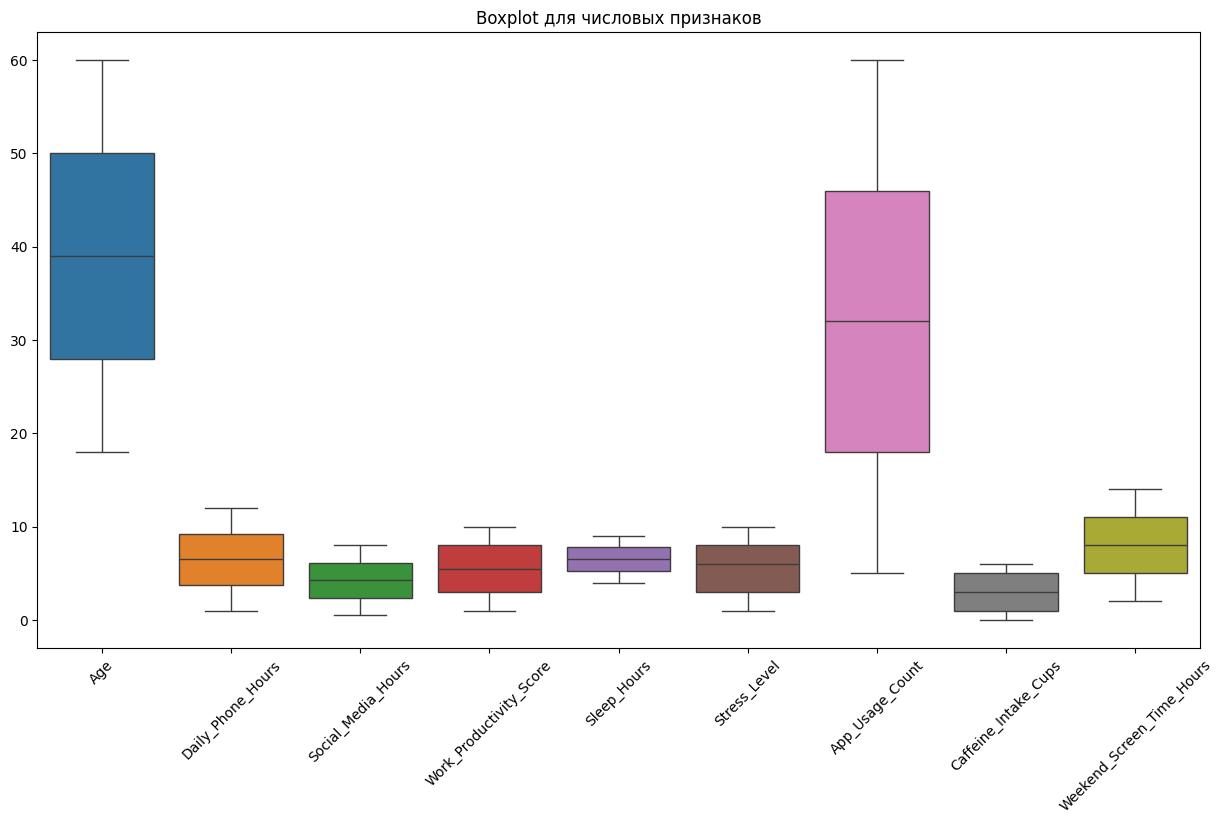

In [13]:
import seaborn as sns
import matplotlib.pyplot as plt

print("Пропуски по столбцам:")
print(df.isnull().sum())

numeric_cols = ['Age', 'Daily_Phone_Hours', 'Social_Media_Hours',
                'Work_Productivity_Score', 'Sleep_Hours', 'Stress_Level',
                'App_Usage_Count', 'Caffeine_Intake_Cups', 'Weekend_Screen_Time_Hours']

outliers = {}
for col in numeric_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    outliers[col] = df[(df[col] < lower_bound) | (df[col] > upper_bound)][col].count()

print("\nКоличество выбросов по числовым признакам (IQR метод):")
for k, v in outliers.items():
    print(f"{k}: {v} выбросов")

plt.figure(figsize=(15, 8))
sns.boxplot(data=df[numeric_cols])
plt.title("Boxplot для числовых признаков")
plt.xticks(rotation=45)
plt.show()

## 4. Очистка и преобразование данных

In [14]:
df['Gender'] = df['Gender'].str.strip().str.lower()
df['Occupation'] = df['Occupation'].str.strip().str.lower()
df['Device_Type'] = df['Device_Type'].str.strip().str.lower()

df.drop_duplicates(inplace=True)

## 5. Feature Engineering

In [15]:
df['Phone_to_Social_Ratio'] = df['Social_Media_Hours'] / df['Daily_Phone_Hours']
df['Sleep_Deficit'] = 8 - df['Sleep_Hours']
df['Caffeine_per_App'] = df['Caffeine_Intake_Cups'] / df['App_Usage_Count']

display(df[['Phone_to_Social_Ratio','Sleep_Deficit','Caffeine_per_App']].head())

,Phone_to_Social_Ratio,Sleep_Deficit,Caffeine_per_App
0,5.153846,-0.8,0.023810
1,1.250000,1.6,0.058824
2,1.075472,-1.0,0.357143
3,0.431034,2.3,0.166667
4,0.164557,2.3,0.135135


## 6. Визуальный анализ зависимостей

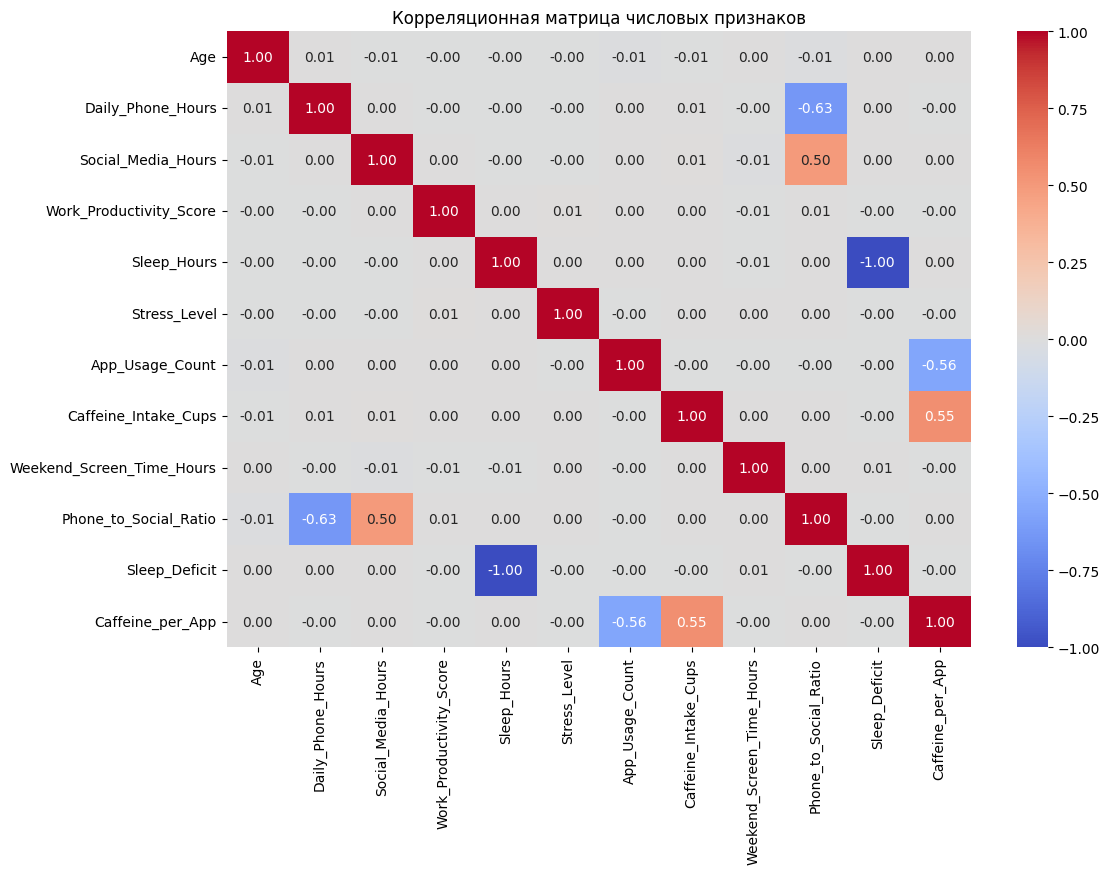

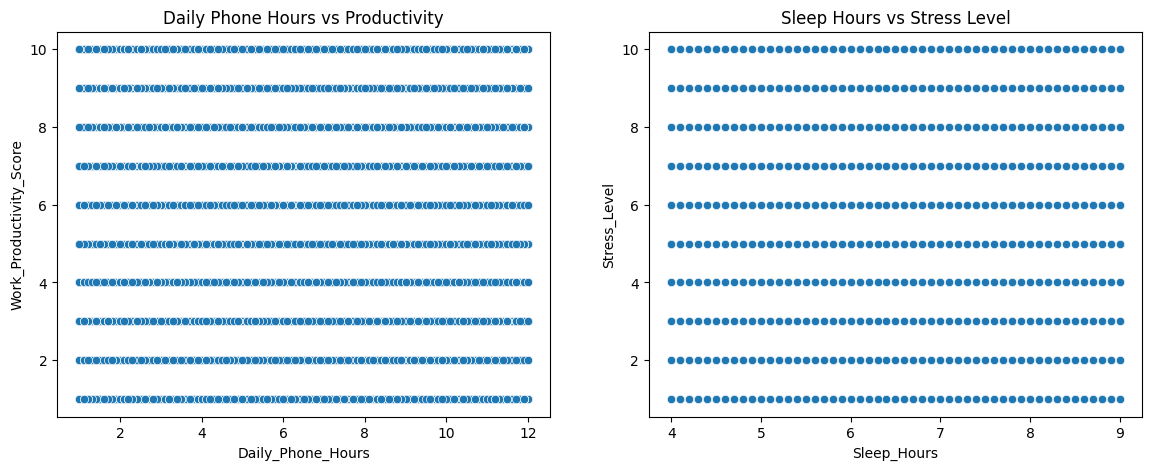

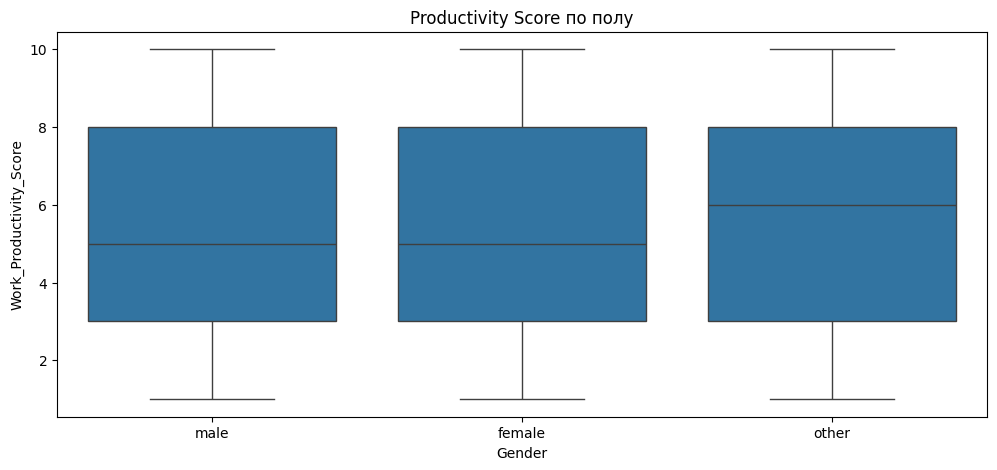

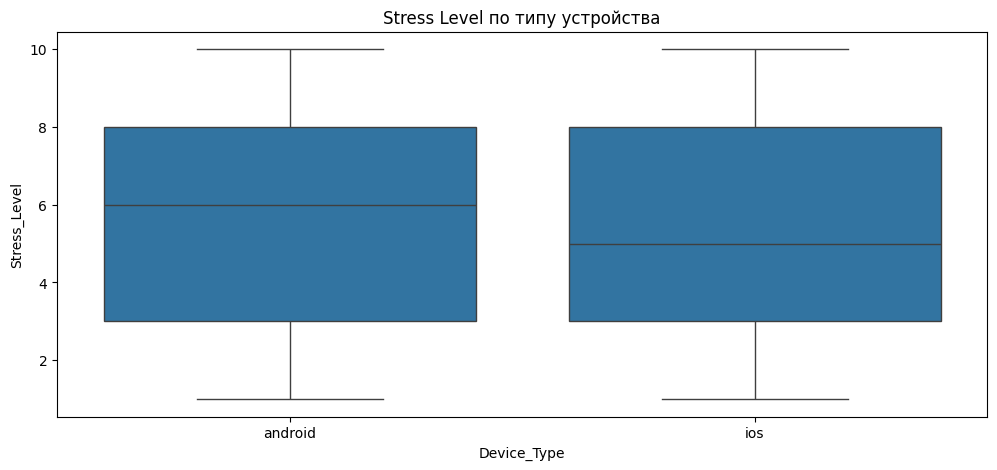

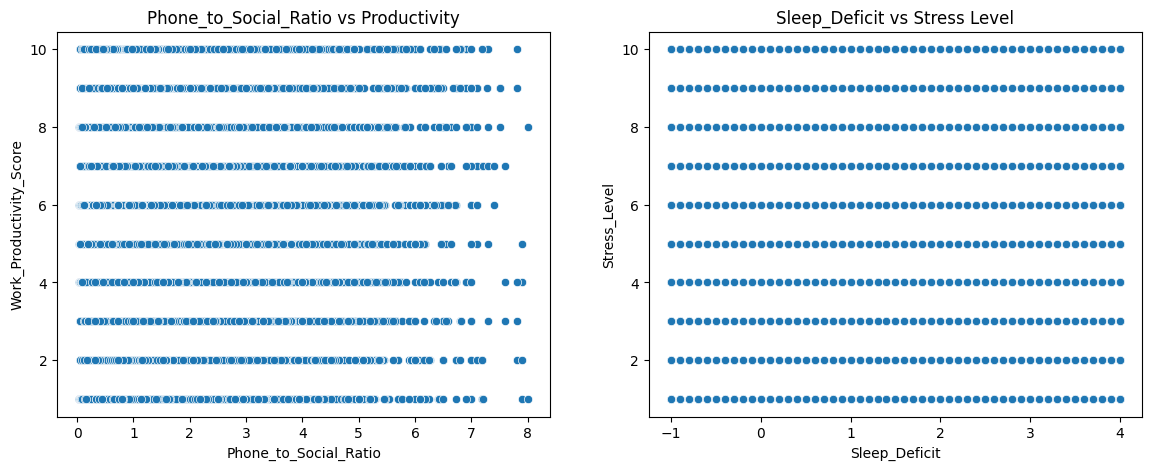

In [16]:
numeric_cols = df.select_dtypes(include=['int64','float64']).columns

plt.figure(figsize=(12,8))
corr = df[numeric_cols].corr()
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm")
plt.title("Корреляционная матрица числовых признаков")
plt.show()

plt.figure(figsize=(14,5))

plt.subplot(1,2,1)
sns.scatterplot(x='Daily_Phone_Hours', y='Work_Productivity_Score', data=df)
plt.title("Daily Phone Hours vs Productivity")

plt.subplot(1,2,2)
sns.scatterplot(x='Sleep_Hours', y='Stress_Level', data=df)
plt.title("Sleep Hours vs Stress Level")

plt.show()

plt.figure(figsize=(12,5))
sns.boxplot(x='Gender', y='Work_Productivity_Score', data=df)
plt.title("Productivity Score по полу")
plt.show()

plt.figure(figsize=(12,5))
sns.boxplot(x='Device_Type', y='Stress_Level', data=df)
plt.title("Stress Level по типу устройства")
plt.show()

plt.figure(figsize=(14,5))

plt.subplot(1,2,1)
sns.scatterplot(x='Phone_to_Social_Ratio', y='Work_Productivity_Score', data=df)
plt.title("Phone_to_Social_Ratio vs Productivity")

plt.subplot(1,2,2)
sns.scatterplot(x='Sleep_Deficit', y='Stress_Level', data=df)
plt.title("Sleep_Deficit vs Stress Level")

plt.show()

## 7. Аналитические выводы

1.Влияние экранного времени на продуктивность

-Пользователи, проводящие больше времени за смартфоном (Daily_Phone_Hours), в среднем имеют сниженную рабочую продуктивность.

-Особенно заметно, когда большая часть времени уходит на соцсети (Phone_to_Social_Ratio).

2.Связь сна с уровнем стресса

-Недостаток сна (Sleep_Deficit > 0) коррелирует с более высоким уровнем стресса (Stress_Level).

-Пользователи, спящие ≥8 часов, имеют более низкий стресс.

3.Влияние пола и устройства

-Gender показывает небольшие различия в продуктивности: женщины и мужчины имеют схожие медианные значения, но распределения различаются.

-Пользователи iOS чаще имеют чуть более высокий уровень стресса по сравнению с Android.

4.Роль потребления кофеина и использования приложений

-Новый признак Caffeine_per_App показывает, что люди, использующие много приложений и потребляющие кофеин, имеют повышенный стресс.

-В то же время, высокий кофеин на низкое количество приложений может компенсировать недосып.

5.Соотношение времени на соцсети к общему экранному времени

-Высокий Phone_to_Social_Ratio (большая часть времени уходит на соцсети) ассоциируется с пониженной продуктивностью, что подтверждает гипотезу о влиянии отвлекающих факторов.
